In [ ]:
# Basic Math
print("hello, this is diffusion ddpm notebook")

hello, this is notebook


# 前置概率计算基础
## 1.联合概率、条件概率、边缘概率
joint/condition/edge  
`P(A, B, C)` 联合概率，A、B、C事件同时发生概率  
`P(C|B,A)` 条件概率，条件B, A下C事件的概率  
`P(A)` 边缘概率，时间A发生的概率，即对联合概率A,B,C的B，C事件加和积分  
关系是  
联合概率 `P(A,B,C) = P(C|B,A)*P(A, B)`  
联合概率 `P(A,B) = P(B|A)*P(A)`  
    若A，B独立则 `P(B|A) = P(B)即P(A,B)=P(B)*P(A)`  
联立则得联合概率 `P(A,B,C) = P(C|B,A)*P(B|A)*P(A)`  

条件概率 `P(B,C|A) = P(A,B,C)/P(A) = P(C|B,A)*P(B|A)`  

## 2. 马尔科夫链假设
当前状态只与上一时刻有关，和之前时刻无关 `A->B->C`如果是马尔科夫链  
那么 `P(A,B,C) = P(C|B,A)*P(B|A)*P(A)`中的`C与A无关，P(C|B,A)= P(C|B)`  
则 `P(A,B,C) = P(C|B)P(B|A)P(A)`  
同理 `P(B,C|A) = P(C|B,A)*P(B|A)=P(C|B)*P(B|A)`

## 3. 高斯分布KL散度
KL散度衡量2个概率分布的相似度，相似度的某种“度量”，2种分布携带信息差异的度量  
概率分布p和概率分布q是高斯分布：   
$p=N(\mu_p,\sigma_p)$, $q=N(\mu_q,\sigma_q)$  
$D_{KL}(p|| q) = D_{KL}(N(\mu_p, \sigma_p)||N(\mu_q,\sigma_q)) \\
=\sum_{i=1}^{N}{p(x_i)*\log(\frac{p(x_i)}{q(x_i)})} \\
=\mathbb E_{x\in p}[\log p(x)-\log q(x)]\\
= \log(\frac{\sigma_q}{\sigma_p}) + \frac{\mu_p^2+(\mu_p-\mu_q)^2}{2\sigma_q^2} -\frac{1}{2}$  
如果$\mu_p == \mu_q$，那么D_{KL} = 0, 假设方差$\sigma$相同，一般都相同简化问题


## 4. 重参数技巧 reparameters
若想采样高斯分布$N(\mu, \sigma)$ 则可以先从标准分布$N(0, 1)$采样出$Z$变量，  
然后使用$x = \sigma*z + \mu$, 这样x服从($\mu$, $\sigma$)的高斯分布，此时只用对标准高斯分布$N(0,1)$采样即可,比较方便  
此时构建一个网络，输入是z变量，好处是可导的对$\sigma, \mu$都是可导的   
那么$\mu, \sigma$就成了网络可以学习的参数


# VAE 
## VAE原理
x是由某个隐变量z得到的，z怎么得到呢？z是通过后验网络$q_\phi$获取  
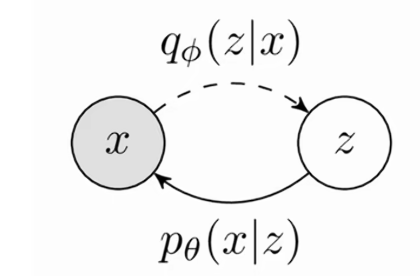  
$p(x) = \int_z{p_\theta(x|z)p(z)}$  没问题条件概率积分变成边缘概率  
$p(x) = \int_z{q_\phi(z|x)\frac{p_\theta(x|z)p(z)}{q_\phi(z|x)}}$  完全等价  
$\log p(x) = log \mathbb E_{z \in q_\phi(z|x)} [\frac {p_\theta(x|z)p(z)} {q_\phi(z|x)}]$  解释为z服从某个概率，对[p/q]的期望  
Json不等式可以获取某个凸函数下界, 而log函数正是一个上凸的函数  
$f(\mathbb E(x)) \ge \mathbb E(f(x))$ 例如$f((x_a+x_b)/2) \ge (f(x_a)+f(x_b))/2$  
即 $\log p(x) \ge \mathbb E_{z \in q_phi(z|x)}[\log \frac{p_theta(x|z)p(z)}{q_phi(z|x)}]$  
将最大化p(x)问题转化为最大化log p(x)单调函数问题，也就是最大化它的下界问题  
下界形式拆分一下，恰恰包含一个KL散度形式 $D_{KL}(p(z)||q_\phi(z|x))$  
一般我们设定 p(x) 服从高斯分布，${q_\phi}$也是一个高斯分布

## 多层VAE原理
x变量通过多个隐变量z1,z2...得到的，即联合概率密度得到  
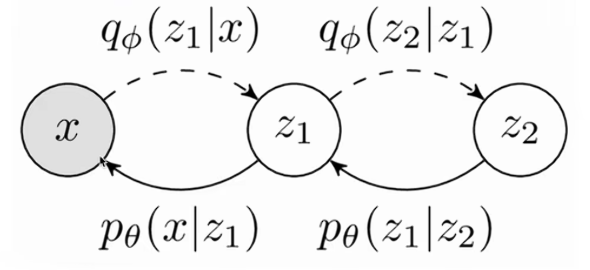  
$p(x, z_1, z_2)=p(x|z_1)p(z_1|z_2)p(z_2)$ 联合概率概率，马尔科夫可以以条件概率链式乘  
$p(x) = \int_{z1}{\int_{z2}{p_\theta(x,z_1, z_2)d_{z1}d_{z2}}}$  没问题联合概率积分变成边缘概率  
同样地凑一个$q_\phi(z_1, z_2|x)$进去  
$p(x) = \int_{z1}{\int_{z2}{q_\phi(z_1, z_2|x)\frac{p_\theta(x,z_1, z_2)}{q_\phi(z_1,z_2|x)}}}$  完全等价   
$p(x) = \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\frac{p_\theta(x,z_1, z_2)}{q_\phi(z_1, z_2|x)}]$ #解释为期望形式  
那么取$\log p(x)$   
$\log p(x) = \log \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\frac{p_\theta(x,z_1, z_2)}{q_\phi(z_1, z_2|x)}]$  
对凸函数log(E(x))取下界 E(log(x))则：  
$\log p(x) \ge  \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\log(\frac{p_\theta(x,z_1, z_2)}{q_\phi(z_1, z_2|x)})]$   
因为整个过程z2->z1->x是一个马尔科夫链过程  
所以分母的联合概率密度$p(x, z_1, z_2)$可以写成  
$p(x, z_1, z_2)=p(x|z_1)p(z_1|z_2)p(z_2)$  
分子的$q_\phi(z_1, z_2|x)$  
$q(z_1, z_2|x) = q(z_1|x)q(z_2|z_1)$  
则下界ELBO可以重新写成  
$$
\begin{align}  
& \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\log(\frac{p_\theta(x,z_1, z_2)}{q_\phi(z_1, z_2|x)})]  \\
& = \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\log(\frac{p_\theta(x|z_1)p_\theta(z_1|z_2)p_\theta(z_2)}{q_\phi(z_1|x) q_\phi(z_2|z_1)})] \\
& = \mathbb E_{z1, z2 \in q_\phi(z1, z2|x)}[\log(p_\theta(x|z_1) - q_\phi(z_1|x) + p_\theta(z_1|z_2) - q_\phi(z_2|z_1) + p_\theta(z_2))] \\
\end{align}
$$

如同diffusion的前向多步扩散和逆向多步采样过程

# Diffusion原理
## 整体概览
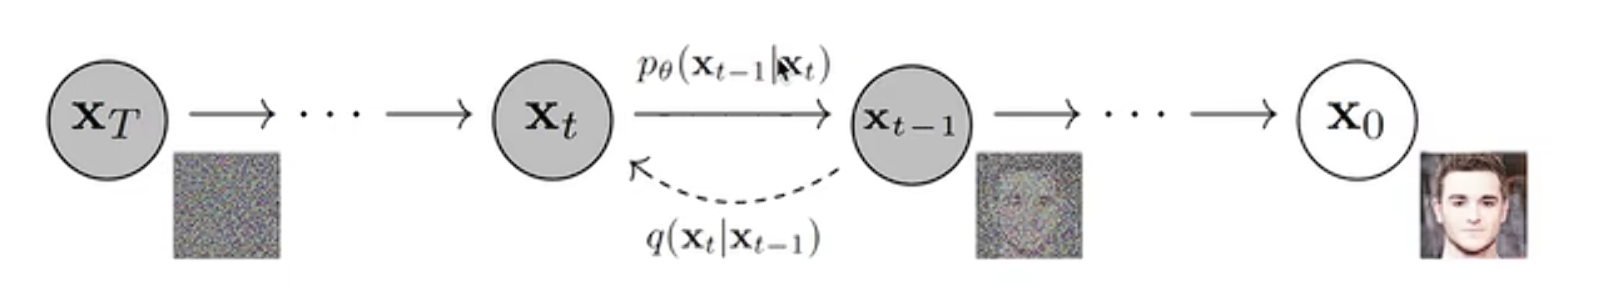

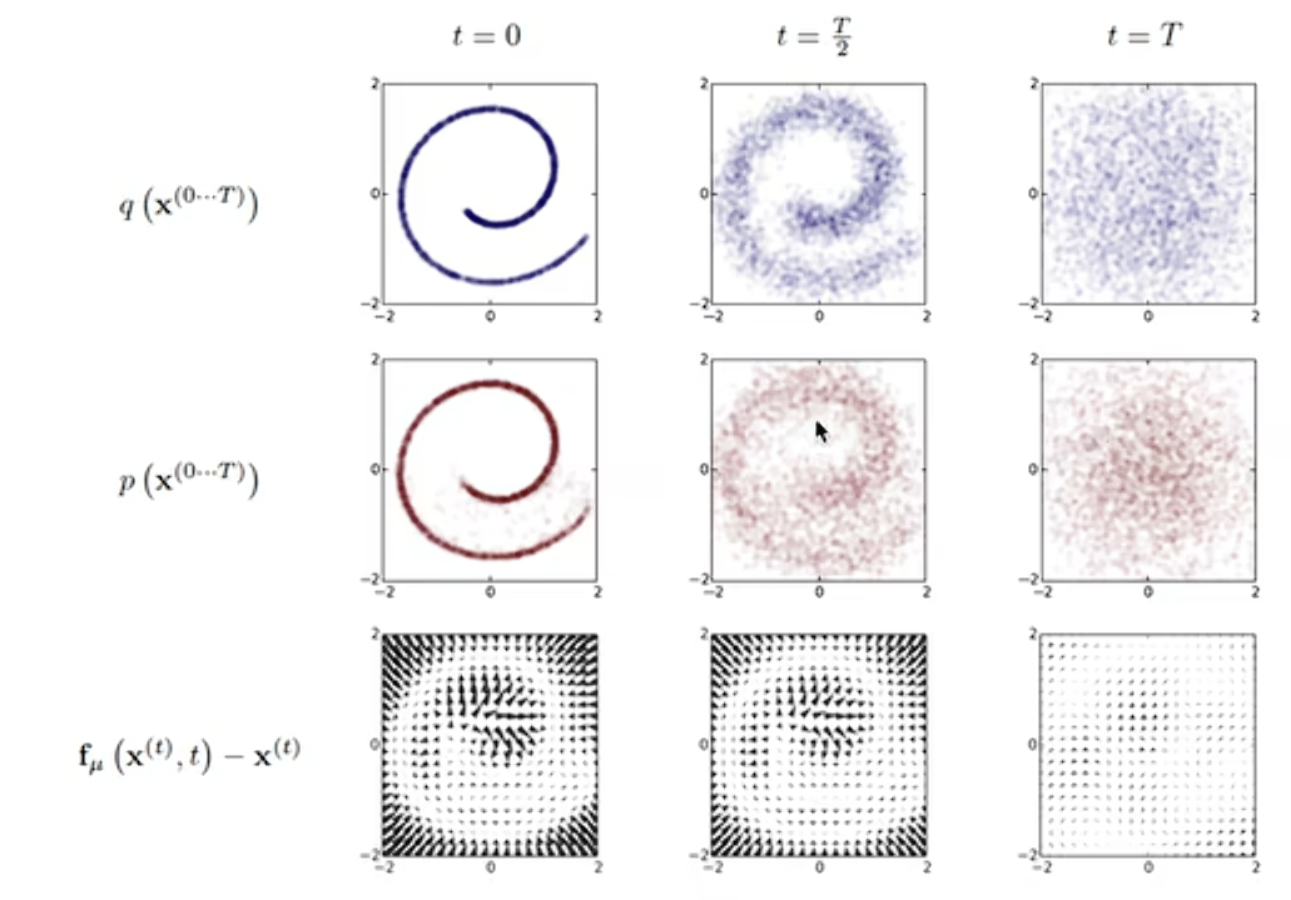
## 扩散过程，熵增过程
X0是清晰图像，其像素分布是真实分布，也就是network要采样生成的最终目标
$X_0->X_{t-1}->X_t -> X_T$  
XT时刻就是最终完全噪声图像

采样过程，逆扩散过程
$X_T->X_t->X_{t-1} -> X_0$  


# 扩散过程 Diffusion Process
$x_0 -> x_T$ 马尔可夫链不断添加噪声，固定比例添加，随着t增大，最终数据分布XT变成变量独立高斯分布  
q加噪声是设计成为服从高斯分布过程，即对一个$X_{t-1}$的随机变量乘以$sqrt(1-beta_t)$得到$X_t$随机变量分布
$q(X_t|X_{t-1}) = N(X_t; \mu, \sigma)$    
$\mu = \sqrt{(1-\beta_t)}X_{t-1},  \sigma = \beta_tI$  
即 $q(X_t|X_{t-1}) = N(X_t; \sqrt{(1-\beta_t)}X_{t-1}, \beta_tI)$  
$\beta_t$是可以成为随着t不断增大的可学习的数值，但通常是个常数  
那么整个过程结合马尔科夫链，联合概率分布$q(X_1, X_2, X_3, ,..X_t, X_T|X_0)$就是  
 $q(X_{1:T}|X_0) = q(X_1|X_0)*q(X_2|X_1)*....q(X_t|X_{t-1})=\prod_{t=1}^{T}q(X_t|X_{t-1})$  

- 利用**重参数化**技巧将独立变量X与Y的分布$p(X)=N(\mu_1, \sigma_1)$和 $p(Y)=N(\mu_2,\sigma_2)$
可以用一个独立变量$Z=aX+bY$来变成只含一个随机变量的分布  
$p(Z) = N(a\mu_1+b\mu_2, \sqrt{a^2\sigma_1^2+b^2\sigma_2^2})$  
- 证明过程：首先利用高斯分布叠加也是高斯分布（要特征值证法），然后求Z分布的均值方差  
$E(Z)=E(zX+bY)=aE(X)+bE(Y) = a\mu_1+b\mu_2$  
$Var(Z)=Var(aX+bY)=a^2Var(X)+b^2Var(Y)+2Cov(aX, bY)$ \\  
因为$Var(X, Y) == 0$ 所以 $Var(Z)=a^2\sigma_1^2+b^2\sigma_2^2$\\

- 利用重参数化技巧将加标准高斯噪声$z_{t-1}, z_{t-2}, z_1$过程合并为一个z  
对$X_t$的图像分布$p(X_t)$加噪声:  
给定 $\alpha_t + \beta_t = 1$  
加标准高斯噪声$z_{t-1}$ 得到 $X_t = \sqrt{\alpha_t}X_{t-1}+\sqrt{1-\alpha_t}z_{t-1}$  
注意这里幅度不同,$X_{t-1}$的幅度是$\sqrt{\alpha}$, 而噪声的幅度是$\sqrt{1-\alpha}$,   
通常$\beta_t$比较小1e-4~1e-2,那么$\alpha_t$比较大,也就是噪声幅度很小的
$$
\begin{align}  
& X_t = \sqrt{\alpha_t}X_{t-1} + \sqrt{1-\alpha_t}z_{t-1}  \\
& = \sqrt{\alpha_t\alpha_{t-1}}X_{t-2} +\sqrt{\alpha_t(1-\alpha_{t-1})}z_{t-2}+\sqrt{1-\alpha_t}z_{t-1} \\
& ....
重参数化技巧\\
&=\sqrt{\alpha_t*\alpha_{t-1}*...\alpha_1}X_0 + \sqrt{1-(\alpha_t*\alpha_{t-1}*...\alpha_1)}z 
\end{align}
$$

那么任意时刻的q概率为 $q(X_t|X_0)=N(X_t; \sqrt{\alpha_t*\alpha_{t-1}*...\alpha_1}X_0, (1-\alpha_t*\alpha_{t-1}*...\alpha_1)I)$  
那么我们想要Xt接近标准高斯分布，那么均值要为0，方差要为1  
所以$\mu系数 \sqrt{\alpha_t*\alpha_{t-1}*...\alpha_1}$要到0  
足够的时间步t之后就可以达到




# 逆扩散、采样
从标准高斯分布X_T中恢复X_0数据，构建一个马尔可夫链   
引入一个$p_\theta$ 网络是为了拟合$q(X_{t-1}|X_t)$这样一个逆过程，因为这个逆过程需要用整个数据（那太困难而且没有泛化性）  
$p_\theta(X_{0:T}) = p(X_T)\prod_{t=1}^T{p_\theta(X_{t-1}|X_t)}$  
$p_\theta(X_{t-1}|X_t) = N(X_{t-1}; \mu_\theta(X_t, t), \Sigma_\theta(X_t,t))$  
带有可学习参数$\theta$的网络$p_\theta$也设计成一个输出是高斯分布的网络，入参只依赖前一步的$X_t$和时间$t$,不依赖所有步数据

那么这个监督数据是什么?$p_\theta$要学习什么呢，他要去近似真实逆过程
$q(X_{t-1}|X_t)$ 但是这个分布不如加条件x0的好推导$q(X_{t-1}|X_t, X_0)$  
我们要最小化2个分布的散度$D_{KL}(q(X_{t-1}|X_t,X_0)||p_\theta(X_{t-1}|X_t)) $  
这2个都是高斯分布简化为去使得均值相同即可（方差一般设置为相同的）
那么需要知道这个$q(X_{t-1}|X_t, X_0)$的均值是多少，才能使得网络$p_\theta$监督学习   
- 推导$q(X_{t-1}|X_t, X_0)$的均值$\mu$
$$
\begin{align}
 & q(X_{t-1}|X_t, X_0) 写出联合概率密度形式 \frac{q(X_{t-1}, X_t, X_0)}{q(X_t, X_0)} \\
 & = \frac{q(X_t, X_{t-1}, X_0)}{q(X_t, X_0)} \\
 & = \frac{q(X_t|X_{t-1}, X_0)*q(X_{t-1}, X_0)}{q(X_t, X_0)} \\
 & = \frac{q(X_t|X_{t-1}, X_0)*q(X_{t-1}|X_0)*q(X_0)}{q(X_t, X_0)} \\
 & = \frac{q(X_t|X_{t-1}, X_0)*q(X_{t-1}|X_0)}{q(X_t, X_0)/q(X_0)} \\
 & = \frac{q(X_t|X_{t-1}, X_0)*q(X_{t-1}|X_0)}{q(X_t|X_0)} 
\end{align}
$$
恰好写成几个条件概率密度相乘形式，这样可以利用定义好的公式  
定义一个连乘 $\bar\alpha_t :=\prod_{t=1}^T{\alpha_t}$  

$q(X_t|X_0) = N(X_t; \sqrt{\bar \alpha_t}X_0, (1-\bar\alpha_t)I)$

$q(X_{t-1}|X_0) = N(X_t; \sqrt{\bar \alpha_{t-1}}X_0, (1-\bar\alpha_{t-1})I)$

$q(X_t|X_{t-1}, X_0) = q(X_t|X_{t-1}) = N(X_t; \sqrt{\alpha_t}X_{t-1}, (1-\alpha_t)I)$  


所以： $q(X_t|X_{t-1}, X_0) *q(X_{t-1}|X_0)/q(X_t|X_0)$
$$
\begin{align}
& \propto \exp(\frac{(x-\sqrt{\bar\alpha_t}X_{t-1})^2}{2(1-\alpha_t)I} + \frac{(x-\sqrt{\bar\alpha_{t-1}}X_0)^2}{2(1-\sqrt{\alpha_{t-1}})I} - \frac{(x-\sqrt{\bar\alpha_{t}}X_0)^2}{2(1-\sqrt{\alpha_{t}})I})  \\
& 因为X_t是X_0加标准高斯噪声z得到，X_t = \sqrt{\bar\alpha_t}X_0 + \sqrt{1-\bar\alpha_t}z \\
& 可以改写一下 X_0 = \frac{X_t - \sqrt{1-\bar\alpha_t}z}{\sqrt{\bar\alpha_t}} 带入上面公式消去X_0\\
& \propto \exp(\frac{(x-\sqrt{\bar\alpha_t}X_{t-1})^2}{2(1-\alpha_t)I} + \frac{(x-\sqrt{\bar\alpha_{t-1}/\bar\alpha_t}(X_t - \sqrt{1-\bar\alpha_t}z))^2}{2(1-\sqrt{\alpha_{t-1}})I} - \frac{(x-(X_t - \sqrt{1-\bar\alpha_t}z))^2}{2(1-\sqrt{\alpha_{t}})I})\\
&上述公式是X_{t-1}的二次方程，\\
& 而最后使用凑方法凑成(x+b/2a)^2 +C
\end{align}
$$
- 最后化简可以推出其分布的均值$\bar\mu(X_t, t) = \frac{1}{\sqrt{\alpha_t}}(X_t -\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}z_t)$
- 网络$p_\theta$要学习的就是这个均值，尽可能KL散度小，注意到均值有个随机分布$z_t \in N(0, I)$



## 逆扩散之最大似然最小KL散度
$p_\theta(X_0)$是概率密度函数，是经过反向去噪网络生成的样本$X_0$的似然概率likelihood，反向过程马尔科夫链的联合概率分布的边缘分布, 即
$p_\theta(X_0) := \int p_\theta(X_{0:T}dx_{1:T})$。  
学习的目的就是让$p_\theta(x_0)$接近真实$q(X_0)$。我们最大化似然即最大化$\log p_\theta(X_0)$对数似然分布。  
为了便于优化，我们通常不直接计算 $p_\theta(X_0)$，而是使用一个可计算的变分下界（Evidence Lower Bound, ELBO）​ 来替代。这个下界由一系列在时间步 t 上的项组成：
$$
-\log p_\theta(X_0) \le -\log p_\theta(X_0) + \log D_{KL}(q(X_{1:T}|X_0)||p_\theta(X_{1:T}|X_0))\\
\le -\log p_\theta(X_0) + \mathbb E_{X_{1:T} \in q(X_{1:T}|X_0)}[\log \frac{q(X_{1:T}|X_0)}{p_\theta(X_{0:T})/p_\theta(X_0)}]\\
=-\log p_\theta(X_0) + \mathbb E_{X_{1:T} \in q(X_{1:T}|X_0)}[\log \frac{q(X_{1:T}|X_{0})}{p_\theta(X_{0:T})} + \log p_\theta(X_0)] \\
= \mathbb E_{X_{1:T} \in q(X_{1:T}|X_0)}[\log \frac{q(X_{1:T}|X_{0})}{p_\theta(X_{0:T})}] \\
$$  
上述$\mathbb E_{X_{1:T} \in q(X_{1:T}|X_0)}[\log \frac{q(X_{1:T}|X_{0})}{p_\theta(X_{0:T})}]$ 即是 $-log p_\theta(X_0)$的上界，最小化其上界即最小化负对数的似然概率。进一步可以化简该上界：  
$$
\mathbb E_{X_{1:T} \in q(X_{1:T}|X_0)}[\log \frac{q(X_{1:T}|X_{0})}{p_\theta(X_{0:T})}] = \\
\mathbb E_q[\log \frac{q(X_T|X_{T-1})*q(X_{T-1}|X_{T-2})*...q(X_1|X_0)}{p_\theta(X_T)*p_\theta(X_{T-1}|X_{T})*...*p_\theta(X_1|X_2)*p_\theta(X_0|X_1)}] \\
=\mathbb E_q[-\log p_\theta(X_T) + \log \frac{q(X_T|X_{T-1})...q(X_2|X_1))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)} + \log \frac{q(X_1|X_0)}{p_\theta(X_0|X_1)}] \\
注意之前推导过的q(X_{T-1}|X_T, X_0)=q(X_T|X_{T-1}, X_0) *q(X_{T-1}|X_0)/q(X_T|X_0) \\
则q(X_T|X_{T-1}, X_0)=q(X_{T-1}|X_T, X_0)/q(X_{T-1}|X_0)*q(X_T|X_0) \\
q是扩散过程，是从0->T的过程q(X_T|X_{T-1}),而加入条件反扩散q(X_{T-1}|X_T, X_0)则需要凑一个概率q(X_{T-1}|X_0)/q(X_T|X_0)\\
带入上式得：
=\mathbb E_q[-\log p_\theta(X_T) + \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)}*\frac{q(X_T|X_0)...q(X_2|X_0)}{q(X_{T-1}|X_0)...q(X_1|X_0)} + \log \frac{q(X_1|X_0)}{p_\theta(X_0|X_1)}]\\
=\mathbb E_q[-\log p_\theta(X_T) + \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)} + \log \frac{q(X_T|X_0)...q(X_2|X_0)}{q(X_{T-1}|X_0)...q(X_1|X_0)} + \log \frac{q(X_1|X_0)}{p_\theta(X_0|X_1)}] \\
=\mathbb E_q[-\log p_\theta(X_T) + \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)} + \log \frac{q(X_T|X_0)}{q(X_1|X_0)} + \log \frac{q(X_1|X_0)}{p_\theta(X_0|X_1)}]
\\
=\mathbb E_q[\log \frac{q(X_T|X_0)}{p_\theta(X_T)} + \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)} - \log {p_\theta(X_0|X_1)}] \\
最后归类为3项：
（1）L_T = \mathbb E_q\log \frac{q(X_T|X_0)}{p_\theta(X_T)}, 即D_{KL}(q(X_T|X_0)||p_\theta(X_T)),X_T是标准高斯分布的，不含学习参数，学习时候可以忽略此项\\
(2) L_{T-1} =\mathbb E_q \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)} 即扩散过程q与逆扩散过程p_\theta的KL散度\\
(3) L_0 = \mathbb E_q[-\log {p_\theta(X_0|X_1)}],即初始时刻，可与（2）一同学习训练\\
$$

论文将$p_\theta(X_{T-1}|X_T)$的方差设置为常数，$p_\theta$对均值$\bar\mu$学习，
$$
L_{T-1} = \mathbb E_q \log \frac{q(X_{T-1}|X_T,X_0)...q(X_1|X_2,X_0))*q(X_0|X_1, X_0)}{p_\theta(X_{T-1}|X_T)...p_\theta(X_1|X_2)p_\theta(X_0|X_1)} \\
$$
q和$p_\theta$都是高斯分布，则其KL散度,即2个高斯分布  
$L_{T-1} = \mathbb E_q[\frac{1}{2\sigma_t^2}(|\bar\mu_t(X_t, X_0) - \mu_\theta(X_t, t)|^2)] + C$  
即学习扩散过程的均值$\bar\mu_t(X_t, X_0)$即可,根据上文推导  
$\bar\mu_t(X_t, t) = \frac{1}{\sqrt{\alpha_t}}(X_t -\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}z_t)$  
注意$X_t$是$X_0$和随机噪声$z$的函数 $X_t = \sqrt{\alpha_t}X_0 + \sqrt{1-\bar\alpha_t}z$  
即令均值形式相同，引入一个可学习的网络$\epsilon_\theta$对$z_t$学习$\mu_\theta(X_t, t) = \frac{1}{\sqrt{\alpha_t}}(X_t -\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(X_t,t))$  
最后$L_{T-1} 简化 L_{simple}(\theta):= \mathbb E_t, x_0, \epsilon[||z_t - \epsilon_\theta(X_t, t)||^2]$ 即对q扩散过程的噪声$z_t$对网络$\epsilon_\theta$输入(Xt, t)进行训练，此定义就是loss函数，能够最小化逆扩散过程$p_\theta$的$X_0$似然概率分布$p_\theta(X_0)$

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve
import torch
from torch import nn

(10000, 3)
shape 2D: (10000, 2)


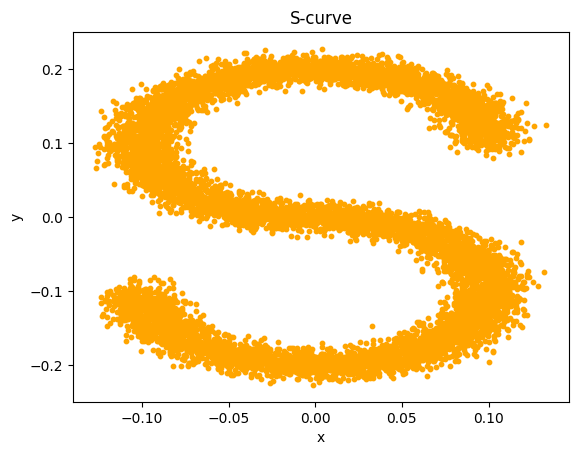

S曲线是若干离散点组成，看作是一种数据分布


In [3]:
s_curve, _ = make_s_curve(10000, noise=0.1)
print(s_curve.shape)
s_curve = s_curve[:, [0, 2]]/10.0 # 只保留x和z坐标，并缩放到0-1范围内
print("shape 2D:",s_curve.shape)
plt.scatter(s_curve[:, 0], s_curve[:, 1], s=10, color="orange")
plt.xlabel("x")
plt.ylabel("y")
plt.title("S-curve")
plt.show()
print("S曲线是若干离散点组成，看作是一种数据分布")

dataset shape: torch.Size([10000, 2])
betas shape: torch.Size([200])
betas shape: torch.Size([200])
alphas prod tensor(0.9999) tensor(0.3630)


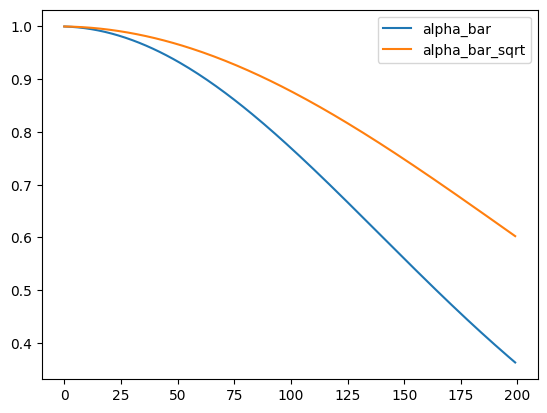

In [4]:
dataset = torch.from_numpy(s_curve).float()
print("dataset shape:", dataset.shape)

# DDMP
noise_steps = 200
betas = torch.linspace(1e-4, 0.01, noise_steps)
alphas = 1.0 - betas
print("betas shape:", betas.shape)

#
alphas_cumprod = torch.cumprod(alphas, dim=0) # 累积乘积，得到每一步的alpha_bar
alphas_bar_sqrt = torch.sqrt(alphas_cumprod) # alpha_bar的平方根
one_minus_alphas_bar_sqrt = torch.sqrt(1.0 - alphas_cumprod) # 1 - alpha_bar的平方根

print("betas shape:", betas.shape)
print("alphas prod", alphas_cumprod[0], alphas_cumprod[-1])

# plot
plt.plot(alphas_cumprod.numpy(), label="alpha_bar")
plt.plot(alphas_bar_sqrt.numpy(), label="alpha_bar_sqrt")
plt.legend()
plt.show()

In [ ]:
# 前向扩散过程 q(x_t | x_0) 
# q(x_t|x_0) = N(x_t; sqrt(alpha_bar_t) * x_0, (1 - alpha_bar_t) * I)
class Diffusion:
    def q_sample(self, x0: torch.Tensor, t: torch.Tensor):
        """
        从前向扩散过程中采样 x_t
        x0: 原始数据，shape (npts, data_dim)
        t: 时间步，shape (nt, 1)
        返回 xt，shape (nt, npts, data_dim)
        """
        # 获取对应时间步的alpha_bar和1-alpha_bar的平方根
        alpha_bar_sqrt_t = alphas_bar_sqrt[t].unsqueeze(-1) # shape (1,1)
        one_minus_alpha_bar_sqrt_t = one_minus_alphas_bar_sqrt[t].unsqueeze(-1) # shape (1,1)
        # 从标准正态分布中采样噪声
        nt, _ = alpha_bar_sqrt_t.shape
        ns, dim = x0.shape
        noise = torch.randn((nt, ns, dim))
        # 计算x_t
        alpha_bar_sqrt_t = alpha_bar_sqrt_t.unsqueeze(1)
        one_minus_alpha_bar_sqrt_t = one_minus_alpha_bar_sqrt_t.unsqueeze(1)  #(n,1,1)
        x0_ext = x0.unsqueeze(0)
        xt = alpha_bar_sqrt_t * x0_ext + one_minus_alpha_bar_sqrt_t * noise

        return xt, noise

 current time batch 66


C:\Users\junqi\AppData\Local\Temp\ipykernel_6920\599454043.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_data.append(torch.tensor(ts))


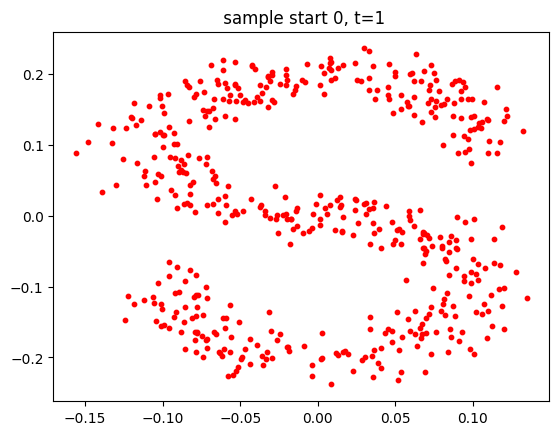

xt_data len: 20


In [ ]:
# 测试前向扩散过程
diffusion = Diffusion()

# 不同时间步
xt_data = []
epsilon_data = []
t_data = []
nsample = 512
nt = noise_steps//3
perm = torch.randperm(dataset.shape[0])
print(" current time batch", nt)
# 遍历所有S-curve分布取出的样本, 这只是1个epoch的数据
for start in range(0, perm.shape[0], nsample):
    x0 = dataset[start:start+nsample, :] # (ntps, 2)
    ts = torch.randint(0, noise_steps, (nt,)) # ()

    xt, epsilon_true = diffusion.q_sample(x0, ts) # (nsample, 2)
    t_data.append(torch.tensor(ts))
    xt_data.append(xt)
    epsilon_data.append(epsilon_true)
    if start % 100 == 0: # 打印一次
        plt.scatter(xt[0, :, 0].numpy(), xt[0, :, 1].numpy(), s=10, color="red")
        plt.title(f" sample start {start}, t={ts[0].item()}")
        plt.show()

print("xt_data len:", len(xt_data)) # (total_steps//t_batch)*(total_n/nsample)

In [52]:
# 1.搭建噪声学习网络epsilon_theta
# 2. 数据学习训练 
#    loss = E[||epsilon - epsilon_theta(x_t, t)||^2]

# 可以选择2种网络架构
# （1）UNet 结构的噪声预测网络
# （2）Transformer 结构的噪声预测网络
class NoisePredictorNet(nn.Module):
    # 此处仅为演示使用简单net结构 MLP
    def __init__(self, num_steps:int, num_units:int=128):
        super(NoisePredictorNet, self).__init__()

        # 时间步嵌入层
        self.embeding = nn.Embedding(num_steps, num_units)

        # 线性层网络, 串联
        # xt 图片 + time embding
        self.linear = nn.Sequential(
                nn.Linear(2+num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, num_units),
                nn.SiLU(),
                nn.Linear(num_units, 2)
        )

    def forward(self, xt:torch.Tensor, t:torch.Tensor) -> torch.Tensor:
        """
        xt: shape (nt, npts, dim=2)
        t: shape (nt, 1)
        返回 epsilon_theta(xt, t)，shape (nt, npts, dim=2)
        """
        
        # t维度到 (nt, )
        t = t.squeeze(-1)
        t_embeding = self.embeding(t) # 时间步嵌入，shape (nt, num_units)
        nt, npts, dim = xt.shape
        t_embeding = t_embeding.unsqueeze(1).expand(-1, npts, -1) # (nt, ntps, num_units)
        # 拼接时间步嵌入和输入
        xt_cat =  torch.cat([xt, t_embeding], dim=-1) # shape (nt, npts, 2 + num_units)
        
        #最后一层线性层输出噪声预测 epsilon_theta
        epsilon_theta_mu = self.linear(xt_cat) # 线性层 (npts, 2)
        return epsilon_theta_mu


 epoch 0/600, loss mean 0.4790
 epoch 50/600, loss mean 0.1695
 epoch 100/600, loss mean 0.2308
 epoch 150/600, loss mean 0.1327
 epoch 200/600, loss mean 0.1199
 epoch 250/600, loss mean 0.0613
 epoch 300/600, loss mean 0.0870
 epoch 350/600, loss mean 0.0831
 epoch 400/600, loss mean 0.1668
 epoch 450/600, loss mean 0.1052
 epoch 500/600, loss mean 0.1459
 epoch 550/600, loss mean 0.1396


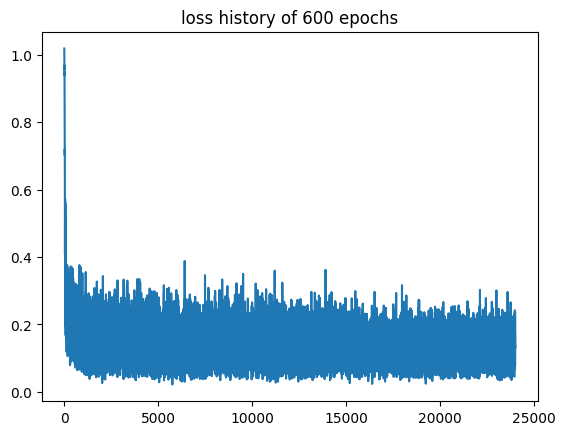

In [ ]:
from torch.optim import AdamW
#  训练噪声学习网络
# 学习 epsilon_theta(xt, t) 来预测噪声
# loss 为 MSE loss = E[||epsilon - epsilon_theta(x_t, t)||^2]
def loss_calculator(epsilon_pred: torch.Tensor, epsilon_true: torch.Tensor) -> torch.Tensor:
    return (epsilon_pred - epsilon_true).square().mean()

# 训练循环
epochs = 600
sample_npts = 256
nt = noise_steps//10

mlpnet = NoisePredictorNet(num_steps=noise_steps)
optimizer = AdamW(mlpnet.parameters(), lr=1e-3)

loss_history = []
for epoch in range(epochs):
    # 训练过程中每个epoch都要遍历整个数据集
    perm = torch.randperm(dataset.shape[0])

    ## 非常重要epoch内循环
    # 保证每个epoch都能看到所有数据，且每个batch随机抽取不同时间步t
    for start in range(0, perm.shape[0], sample_npts):
        # x0图像数据
        x0 = dataset[start:start+sample_npts] # shape (npts, dim)

        # 取出batch个t时间步
        t = torch.randint(0, noise_steps, size=(nt,))

        # 从前向扩散过程中对1个x0在多个时间步t采样 xt, 记录真实noise
        xt, noise_true = diffusion.q_sample(x0, t) # shape (npts, dim)

        # 模型预测当前xt，t的噪声
        epsilon_pred = mlpnet(xt, t) # [nt, npts, dim]

        # 计算预测和真实噪声的loss
        cur_loss = loss_calculator(noise_true, epsilon_pred)

        # 反向传播计算
        optimizer.zero_grad() # grad 清零
        cur_loss.backward()
        # 根据loss更新模型
        optimizer.step()
        ##
        loss_history.append(cur_loss.item())

    if epoch % 50 == 0:
        print(f" epoch {epoch}/{epochs}, loss mean {loss_history[-1]:.4f}")    

torch.save(mlpnet.state_dict(), "mlpnet_state_dict.pt")
plt.plot(loss_history)
plt.title(f"loss history of {epochs} epochs")
plt.show()


 current time180 / totaltime 200
 current time160 / totaltime 200
 current time140 / totaltime 200
 current time120 / totaltime 200
 current time100 / totaltime 200
 current time80 / totaltime 200
 current time60 / totaltime 200
 current time40 / totaltime 200
 current time20 / totaltime 200
 current time18 / totaltime 200
 current time16 / totaltime 200
 current time14 / totaltime 200
 current time12 / totaltime 200
 current time10 / totaltime 200
 current time8 / totaltime 200
 current time6 / totaltime 200
 current time4 / totaltime 200
 current time2 / totaltime 200
 current time0 / totaltime 200


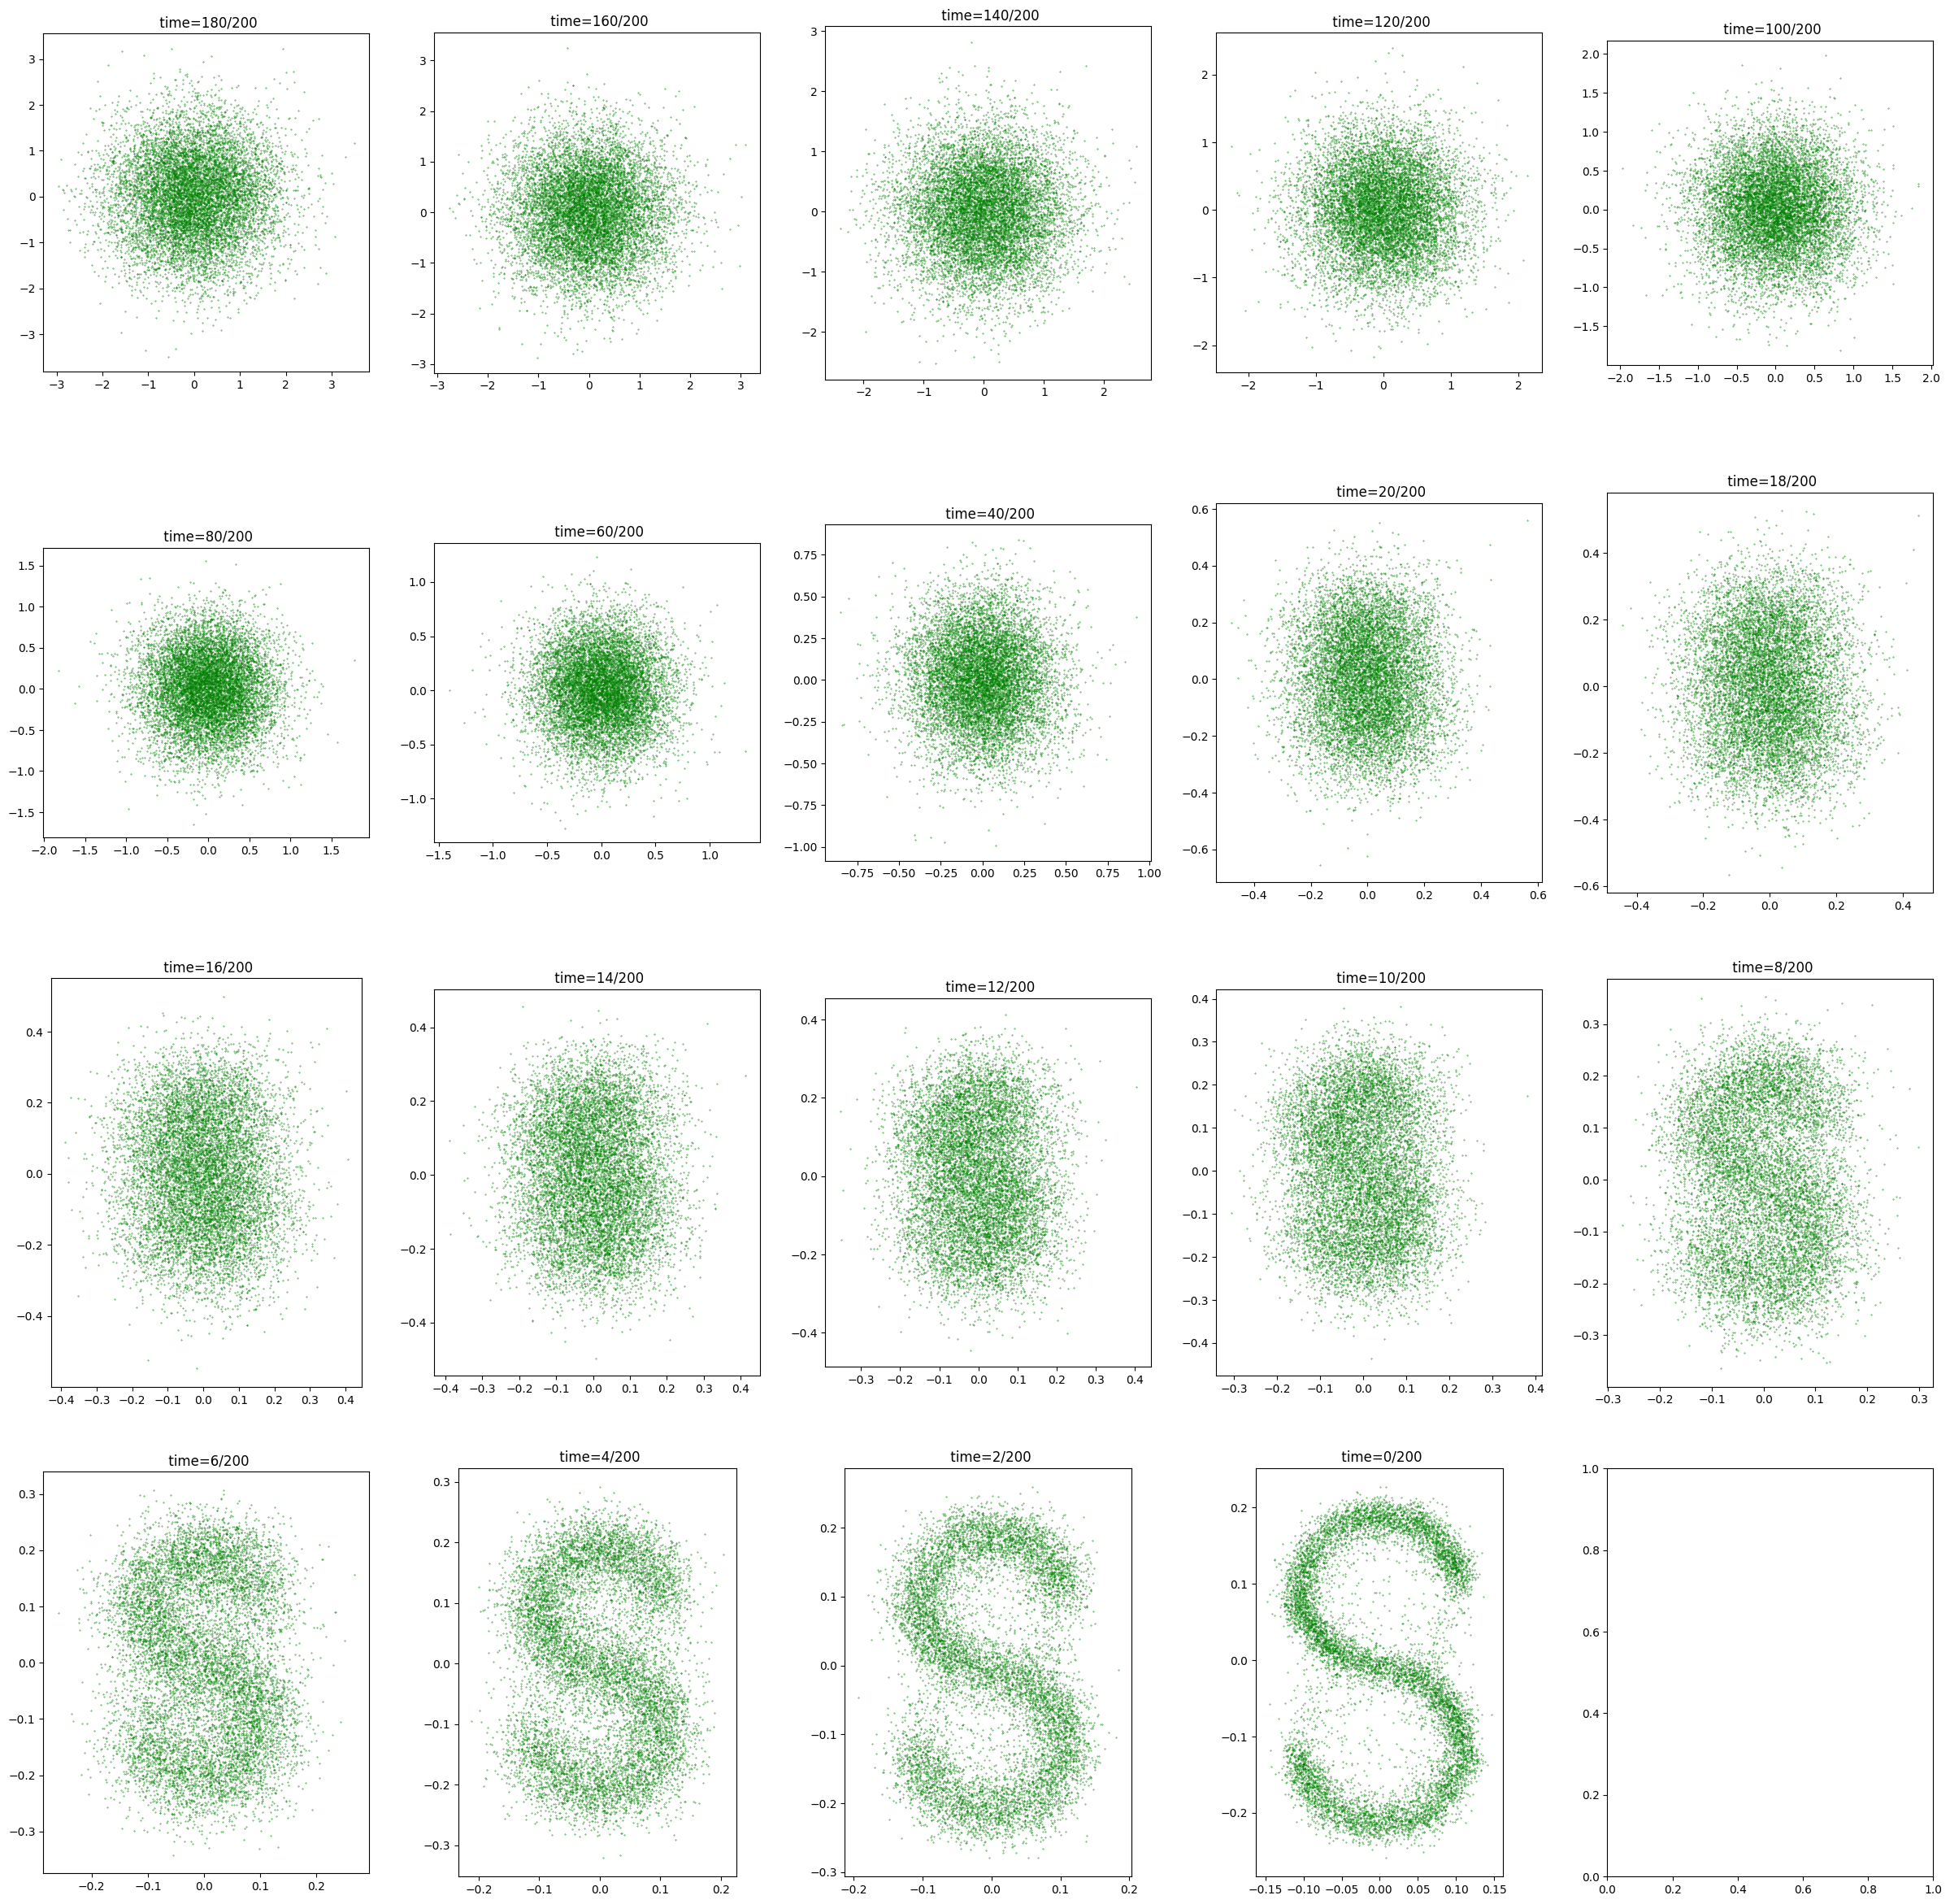

 inferred the last x0


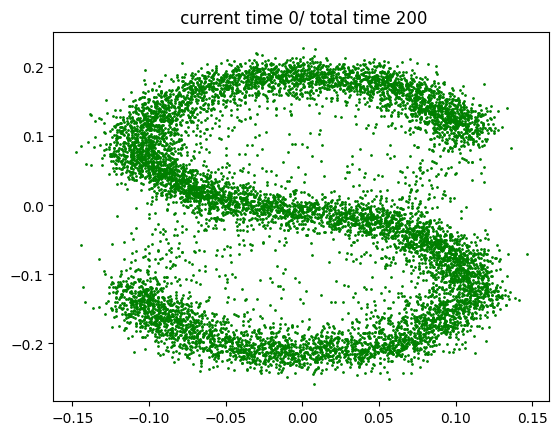

In [ ]:
# 逆扩散采样
# p(x_t-1|x_t) = N(mu_t, I) + sigma_t*z
# x_t-1 = 1/sqrt(alpha_t)(xt - beta_t/sqrt(1-alpha_bar_t)*epsilon_theta(xt, t)) + sigma_t*z
# sigma_t assumpted to be sqrt(beta_t)
def sampling(xt: torch.Tensor, t: torch.Tensor)->torch.Tensor:
    """
    逆扩散采样
    xt shape (ntps, dim)
    t shape (1,)
    """
    rep = 1.0/(alphas[t].sqrt()+1e-15)
    rep = rep.unsqueeze(-1) # shape (1, 1)
    coeff = betas[t] / (one_minus_alphas_bar_sqrt[t] + 1e-15)
    coeff = coeff.unsqueeze(-1) # shape (1, 1)
    # 模型预测当前xt，t的噪声
    xt_ext = xt.unsqueeze(0) # (1, npts, dim)
    t_ext = t.unsqueeze(-1) #(1, 1)
    epsilon_pred = mlpnet(xt_ext, t_ext) #(1, npts, dim)
    epsilon_pred = epsilon_pred.squeeze(0) # (npts, dim)
    # 均值路径
    mean_walk = rep*(xt - coeff*epsilon_pred)
    # 随机路径
    z = torch.randn_like(xt) # 标准正态分布噪声
    rnd_walk = torch.sqrt(betas[t]).unsqueeze(-1)* z

    # 恢复图像
    if t[0] > 0:
        xtm1 = mean_walk + rnd_walk
    else:
        xtm1 = mean_walk # 最后一步不加随机噪声
    return xtm1

def plot_tensor_image(xt: torch.Tensor, ti, steps):
    plt.scatter(xt[:, 0].detach().numpy(), xt[:, 1].detach().numpy(),
                s=1, color="green")
    plt.title(f" current time {ti}/ total time {steps}")
    plt.show()


# 高斯分布
xT = torch.randn(dataset.shape) # shape (n, dim)
# plot_tensor_image(xT, noise_steps, noise_steps)

# 逐步恢复 from t=T to t = 0
xt = xT
frames = []
for ti in reversed(range(noise_steps)):
    t = torch.tensor([ti]) # shape (1,)
    xt = sampling(xt, t) # shape (npts, dim)
    if ti % 20 == 0 or (ti < 20 and ti%2 == 0):
        print (f" current time{ti} / totaltime {noise_steps}")
        frames.append((xt.clone().detach().numpy(), ti))

fig, ax = plt.subplots(len(frames)//5+1, 5, figsize=(30, 30))
for i, (xt, ti) in enumerate(frames):
    idx = i // 5
    idj = i - idx*5
    ax[idx, idj].scatter(xt[:, 0], xt[:, 1],
                s=0.1, color="green")
    ax[idx, idj].set_title(f" time={ti}/{noise_steps}")
    ax[idx, idj].set_aspect('equal')

plt.show()

print(" inferred the last x0")
plot_tensor_image(xt, ti, noise_steps)